In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [11]:
df["Date"]=pd.to_datetime(df["Date"])
df["Date"].dtype

dtype('<M8[ns]')

In [12]:
df["Month"]=df["Date"].dt.to_period("M")

In [13]:
monthly_sales=df.groupby("Month")["Total Amount"].sum()
monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

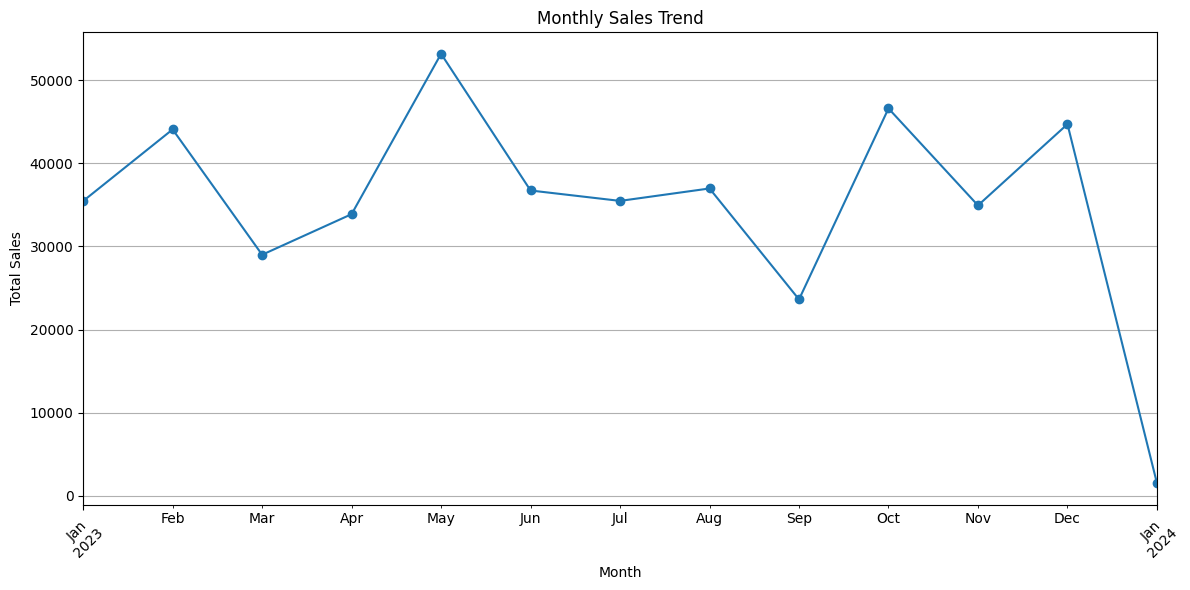

In [14]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [15]:
df['Quarter'] = df['Date'].dt.to_period('Q')

In [16]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

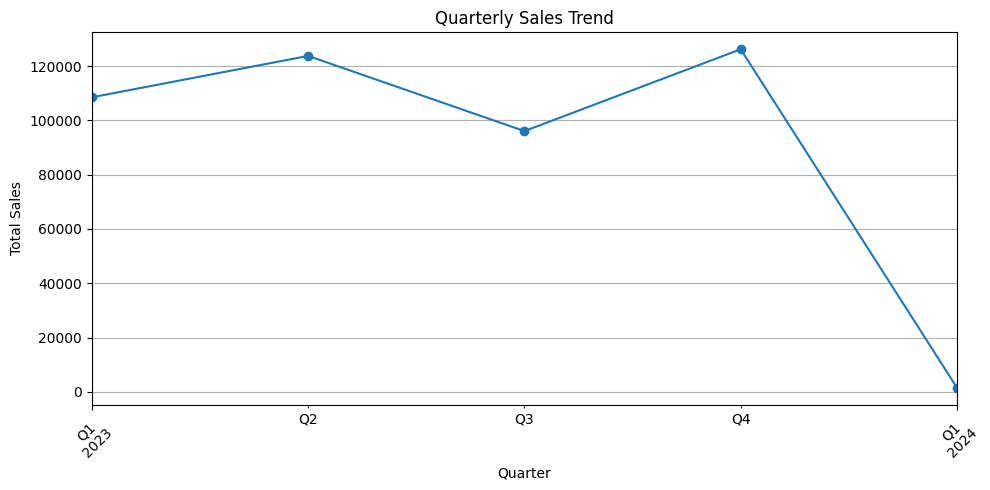

In [17]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

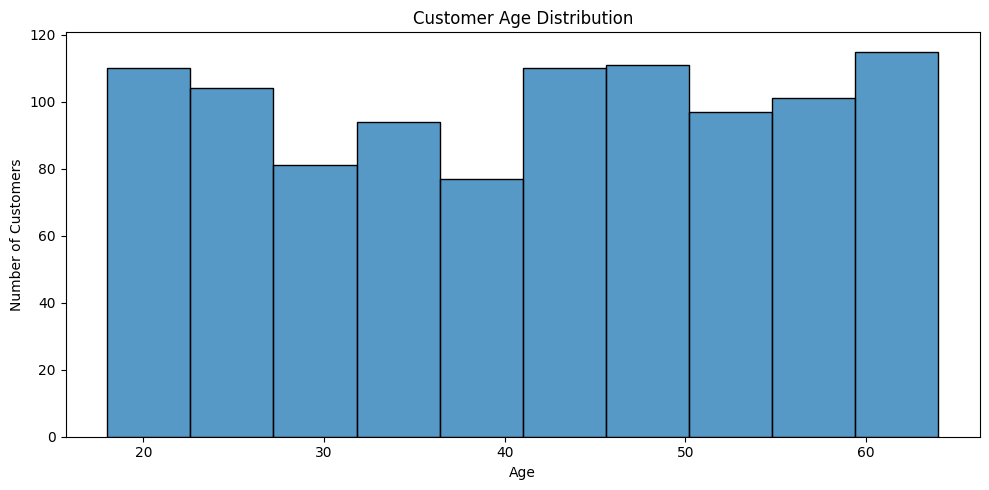

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='Age', bins=10)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()

plt.show()

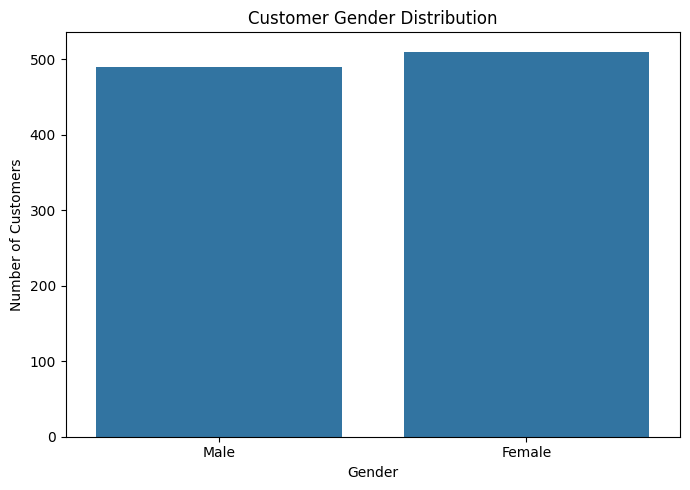

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Gender')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()

plt.show()

In [20]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)

top_products

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

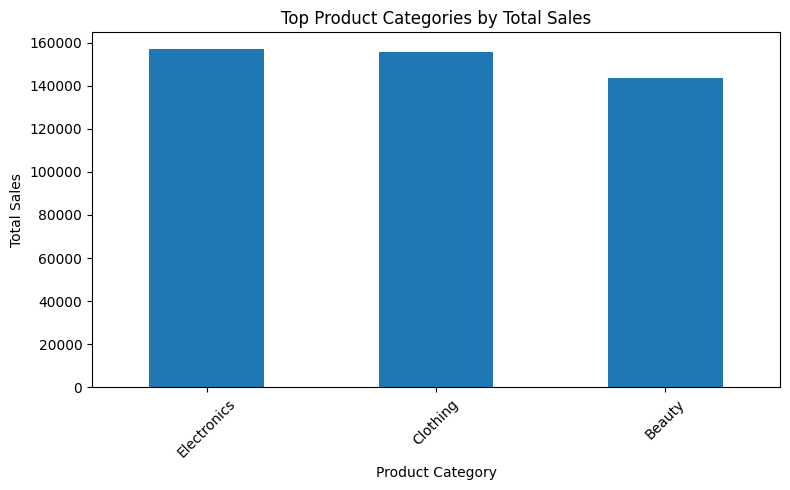

In [21]:
plt.figure(figsize=(8, 5))

top_products.plot(kind='bar')

plt.title('Top Product Categories by Total Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

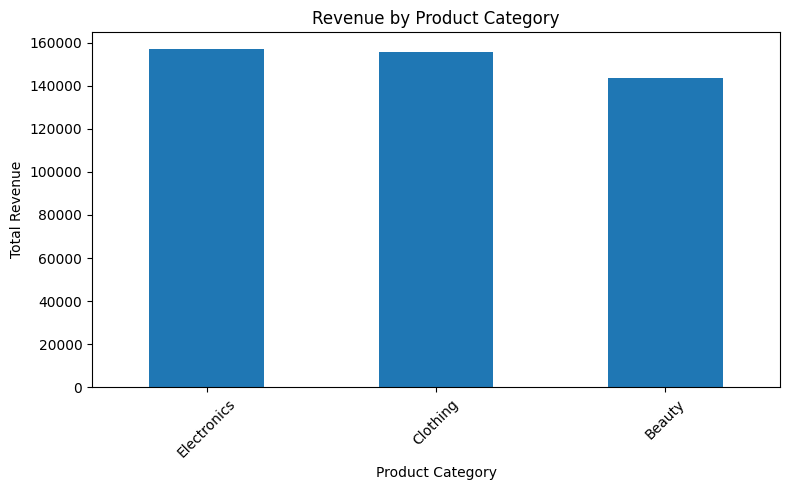

In [23]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [24]:
correlation = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


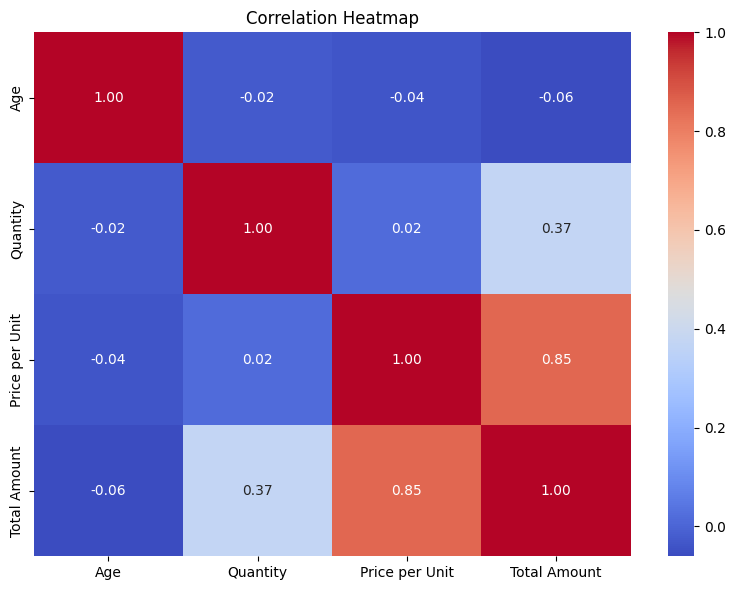

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()

plt.show()

In [26]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

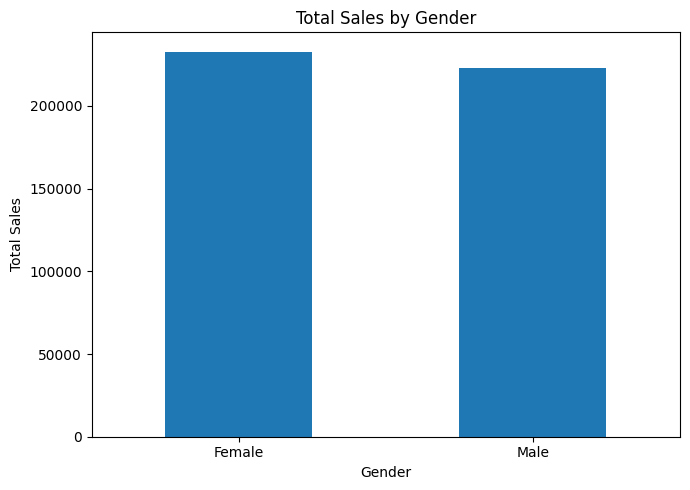

In [27]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [28]:
category_revenue.idxmax(), category_revenue.max()

('Electronics', np.int64(156905))

In [29]:
category_revenue.idxmin(), category_revenue.min()

('Beauty', np.int64(143515))

In [30]:
gender_sales.idxmax(), gender_sales.max()

('Female', np.int64(232840))

In [31]:
df['Age'].mean()

np.float64(41.392)

In [32]:
monthly_sales.idxmax(), monthly_sales.max()

(Period('2023-05', 'M'), np.int64(53150))

In [33]:
quarterly_sales.idxmax(), quarterly_sales.max()

(Period('2023Q4', 'Q-DEC'), np.int64(126190))

## Key Insights

- Electronics generated the highest total revenue among the product categories.
- Beauty generated the lowest total revenue among the product categories.
- Female customers contributed higher total sales than male customers.
- The average customer age is approximately 41.39 years.
- May 2023 recorded the highest monthly sales.
- The fourth quarter of 2023 recorded the highest quarterly sales.

## Business Recommendations

- Focus on maintaining and expanding the Electronics category due to its strong sales performance.
- Investigate the lower performance of the Beauty category and consider targeted promotions or product improvements.
- Develop targeted marketing strategies based on customer demographics and purchasing patterns.
- Plan promotional campaigns around periods with historically stronger sales.
- Continue monitoring monthly and quarterly sales trends to support inventory and marketing decisions.